---

# PIE CHARTS & SCATTERPLOTS

---

>- **Pie Charts** are used for showing composition with categorical data
>  
>- Pie charts get a bad rap, but they can be effective as long as:
>  
>   - Number of categories <=5
>   - Slices are sorted
>   - First slice starts at 0°

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
retail = pd.read_csv('Data/retail_2016_2017.csv', parse_dates=['date'])

retail = retail.query("family in ['BEVERAGES', 'LIQUOR,WINE,BEER', 'PREPARED FOODS'] and store_nbr in [44, 45]")

df_plot1 = retail.groupby('family')[['sales']].sum().sort_values('sales', ascending=False)
df_plot1

,sales
family,
BEVERAGES,1.169406e+07
PREPARED FOODS,4.616506e+05
"LIQUOR,WINE,BEER",3.361750e+05


array([<Axes: >], dtype=object)

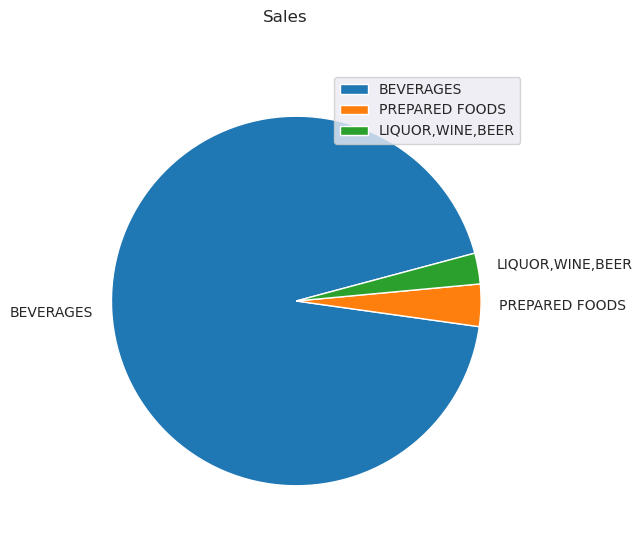

In [3]:
sns.set_style('darkgrid')

df_plot1.plot.pie(
    figsize=(9,6),
    subplots=True,
    title='Sales',
    ylabel='',
    startangle=15,
)

<br><br>

---

## Scatterplots

>**Scatterplots** are used for showing the relationship between numerical series
>

In [4]:
df_scatter = (retail
    .query("family in ['BEVERAGES', 'LIQUOR,WINE,BEER','PREPARED FOODS'] and sales > 390")
    .pivot_table(index='date', columns='family', values='sales', aggfunc='sum')
    .dropna()
)

df_scatter

family,BEVERAGES,"LIQUOR,WINE,BEER",PREPARED FOODS
date,,,
2016-01-02,29474.0,1087.0,1089.33603
2016-01-08,17214.0,1049.0,529.67800
2016-01-09,27175.0,1456.0,1266.71800
2016-01-15,16223.0,1160.0,543.31400
2016-01-16,26331.0,1767.0,1141.66500
...,...,...,...
2017-04-15,25940.0,907.0,442.66000
2017-04-29,27404.0,1205.0,410.46002
2017-05-06,29809.0,513.0,835.80300


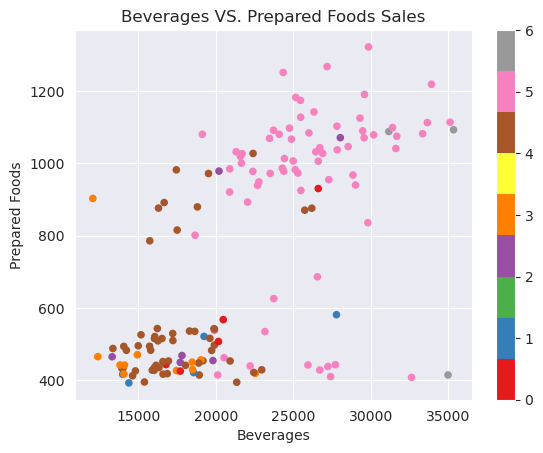

In [16]:
df_scatter.plot.scatter(x='BEVERAGES', 
                        y='PREPARED FOODS',
                        title='Beverages VS. Prepared Foods Sales',
                        xlabel='Beverages',
                        ylabel='Prepared Foods',
                        c=df_scatter.reset_index().date.dt.dayofweek,
                        colormap='Set1');

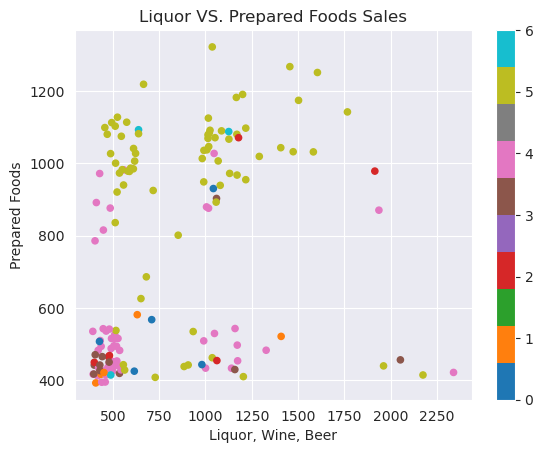

In [17]:
df_scatter.plot.scatter(x='LIQUOR,WINE,BEER', 
                        y='PREPARED FOODS',
                        title='Liquor VS. Prepared Foods Sales',
                        xlabel='Liquor, Wine, Beer',
                        ylabel='Prepared Foods',
                        c=df_scatter.reset_index().date.dt.dayofweek,
                        colormap='tab10');

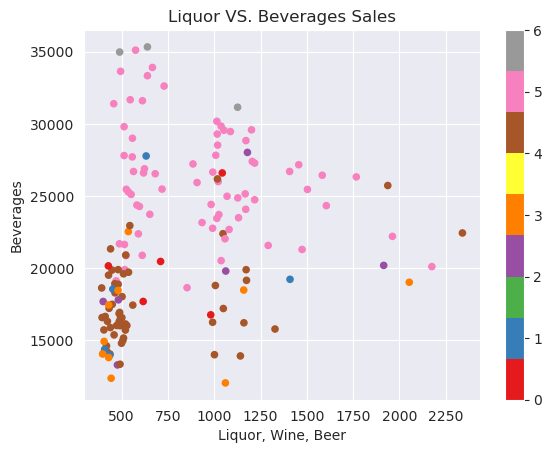

In [18]:
df_scatter.plot.scatter(x='LIQUOR,WINE,BEER', 
                        y='BEVERAGES',
                        title='Liquor VS. Beverages Sales',
                        xlabel='Liquor, Wine, Beer',
                        ylabel='Beverages',
                        c=df_scatter.reset_index().date.dt.dayofweek,
                        colormap='Set1'
                       );

---

## LABORATORY

In [22]:
transactions = pd.read_csv('Data/transactions.csv', parse_dates=['date'])

stores = list(range(40,50))

df_bar = (transactions
    .query("store_nbr in @stores and date.dt.month in [1, 2, 3]")
    .pivot_table(index=transactions.date.dt.month, columns='store_nbr', values='transactions', aggfunc='sum')
    .apply(lambda x: (x/sum(x))*100, axis=1)
)
df_bar

store_nbr,40,41,42,43,44,45,46,47,48,49
date,,,,,,,,,,
1,5.052344,4.042938,1.763867,5.138606,17.117285,14.664028,14.238927,15.493529,11.958631,10.529844
2,5.143092,4.116339,1.790748,5.365099,16.760887,14.676416,14.150929,15.481162,12.115043,10.400287
3,5.194765,4.062374,1.760438,5.299201,17.045413,14.589956,14.046847,15.449572,11.968187,10.583246


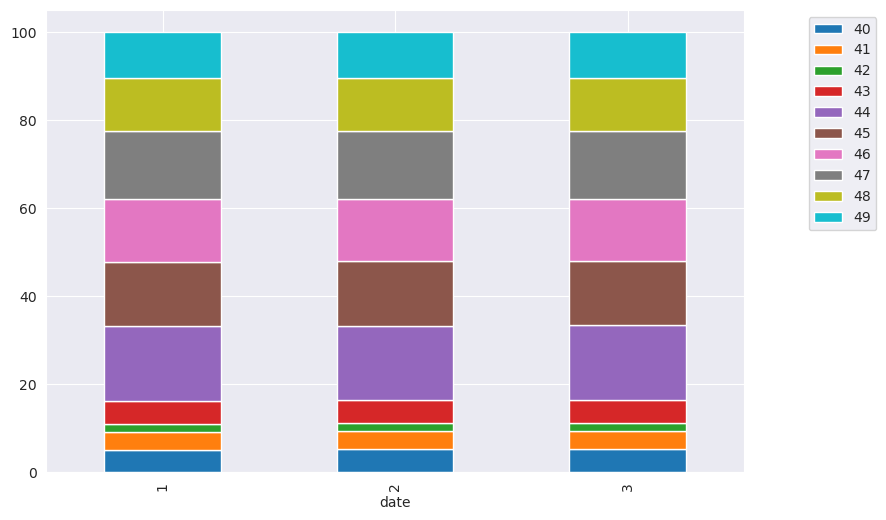

In [27]:
df_bar.plot.bar(
    figsize=(9,6),
    stacked=True,
    cmap='tab10'
).legend(bbox_to_anchor=(1.2, 1));

In [28]:
transactions

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922
...,...,...,...
83483,2017-08-15,50,2804
83484,2017-08-15,51,1573
83485,2017-08-15,52,2255
83486,2017-08-15,53,932


In [31]:
df_pie = (transactions
    .query("store_nbr in @stores and date.dt.month in [1, 2, 3]")
    .groupby('store_nbr')
    .agg({'transactions':'sum'})
)
df_pie

,transactions
store_nbr,
40,564515
41,448122
42,194871
43,579435
44,1868114
45,1610965
46,1556157
47,1702525
48,1321544


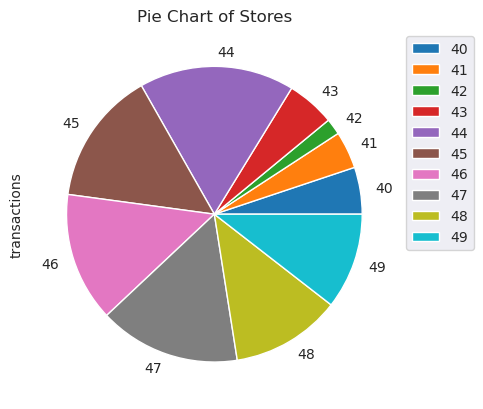

In [37]:
df_pie.plot.pie(
    y='transactions',
    title='Pie Chart of Stores',
).legend(bbox_to_anchor=(1,1));

In [38]:
transactions

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922
...,...,...,...
83483,2017-08-15,50,2804
83484,2017-08-15,51,1573
83485,2017-08-15,52,2255
83486,2017-08-15,53,932


In [46]:
df_scatter2 = (transactions
    .query("store_nbr in @stores")
    .pivot_table(index=transactions.date.dt.month,
                columns='store_nbr',
                values='transactions',
                aggfunc='sum')
)

df_scatter2

store_nbr,40,41,42,43,44,45,46,47,48,49
date,,,,,,,,,,
1,185490,148431,64758,188657,628438,538370,522763,568824,439045,386589
2,179215,143437,62400,186951,584046,511411,493100,539453,422158,362406
3,199810,156254,67713,203827,655630,561184,540294,594248,460341,407071
4,194785,152869,66870,195502,637139,549474,535584,586216,454378,402373
5,208281,166079,69883,202376,671126,570956,554270,597380,469508,421413
6,196988,155688,67692,190156,631016,541302,516034,562559,436015,401579
7,203107,161205,70549,201074,645571,563700,531886,577574,454707,407053
8,182747,146306,63371,182532,596279,514143,485675,524983,419362,365448
9,151905,119653,64763,146055,516233,422178,412455,455021,353820,317871


<Axes: xlabel='44', ylabel='45'>

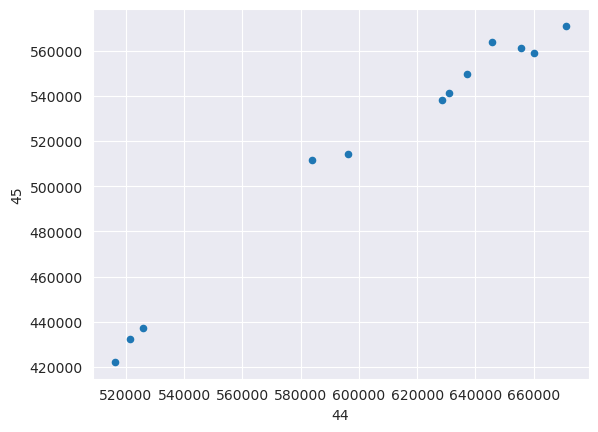

In [47]:
df_scatter2.plot.scatter(x=44, y=45)